In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('Qall_car_data.csv')
df

,City,Name,Year,Price,Kilometers Driven,KM,State,Transmission,Fuel Type,EMI per Month
0,delhi-ncr,Ford Figo Aspire,2016,387000.0,29K km,29000,DL,manual,petrol,6178.0
1,delhi-ncr,Kia Seltos,2021,1049000.0,89K km,89000,DL,manual,petrol,18040.0
2,delhi-ncr,Hyundai Grand i10,2018,509000.0,40.5K km,40500,UP,automatic,petrol,8667.0
3,delhi-ncr,Maruti Wagon R 1.0,2023,527000.0,8K km,8000,HR,manual,petrol,9418.0
4,delhi-ncr,Maruti Ertiga,2014,502000.0,79K km,79000,UP,manual,petrol,10773.0
...,...,...,...,...,...,...,...,...,...,...
10236,jaipur,Ford Figo Aspire,2019,529000.0,63.5K km,63500,RJ,manual,diesel,8631.0
10237,jaipur,Hyundai Elite i20,2020,599000.0,42.5K km,42500,RJ,manual,petrol,10422.0
10238,jaipur,Hyundai Creta,2020,1439000.0,48K km,48000,RJ,automatic,diesel,25287.0
10239,jaipur,Maruti Wagon R 1.0,2016,392000.0,36.5K km,36500,RJ,automatic,petrol,7160.0


DATA EXPLORATION

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10241 entries, 0 to 10240
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               10241 non-null  object 
 1   Name               10241 non-null  object 
 2   Year               10241 non-null  int64  
 3   Price              10239 non-null  float64
 4   Kilometers Driven  10241 non-null  object 
 5   KM                 10241 non-null  int64  
 6   State              10239 non-null  object 
 7   Transmission       10241 non-null  object 
 8   Fuel Type          10235 non-null  object 
 9   EMI per Month      10105 non-null  float64
dtypes: float64(2), int64(2), object(6)
memory usage: 800.2+ KB


In [6]:
df.head()

,City,Name,Year,Price,Kilometers Driven,KM,State,Transmission,Fuel Type,EMI per Month
0,delhi-ncr,Ford Figo Aspire,2016,387000.0,29K km,29000,DL,manual,petrol,6178.0
1,delhi-ncr,Kia Seltos,2021,1049000.0,89K km,89000,DL,manual,petrol,18040.0
2,delhi-ncr,Hyundai Grand i10,2018,509000.0,40.5K km,40500,UP,automatic,petrol,8667.0
3,delhi-ncr,Maruti Wagon R 1.0,2023,527000.0,8K km,8000,HR,manual,petrol,9418.0
4,delhi-ncr,Maruti Ertiga,2014,502000.0,79K km,79000,UP,manual,petrol,10773.0


In [7]:
df.describe()

,Year,Price,KM,EMI per Month
count,10241.000000,1.023900e+04,10241.000000,10105.000000
mean,2018.042476,6.094969e+05,52005.858803,11265.972588
std,3.335570,3.567807e+05,29327.885502,5921.962671
min,2010.000000,1.250000e+05,500.000000,2525.000000
25%,2016.000000,3.840000e+05,29000.000000,7509.000000
50%,2018.000000,5.220000e+05,47500.000000,9698.000000
75%,2021.000000,7.410000e+05,70500.000000,13231.000000
max,2025.000000,4.100000e+06,150000.000000,70516.000000


In [8]:
df.isna().sum()

City                   0
Name                   0
Year                   0
Price                  2
Kilometers Driven      0
KM                     0
State                  2
Transmission           0
Fuel Type              6
EMI per Month        136
dtype: int64

DATA CLEANING

In [10]:
# Handle missing values
df['EMI per Month'].fillna(df['EMI per Month'].median(), inplace=True)
df['Price'].fillna(df['Price'].median(), inplace=True)
df['Fuel Type'].fillna(df['Fuel Type'].mode()[0], inplace=True)

In [11]:
df.isna().sum()

City                 0
Name                 0
Year                 0
Price                0
Kilometers Driven    0
KM                   0
State                2
Transmission         0
Fuel Type            0
EMI per Month        0
dtype: int64

In [12]:
# Check cardinality of categorical columns
categorical_columns = ['City', 'Name', 'State', 'Transmission', 'Fuel Type']

for column in categorical_columns:
    unique_values = df[column].nunique()
    print(f"{column}: {unique_values} unique values")

City: 13 unique values
Name: 168 unique values
State: 13 unique values
Transmission: 2 unique values
Fuel Type: 4 unique values


DATA TRANFORMING

In [25]:
# Create new features
df['Age'] = 2025 - df['Year']  # Current year is 2025


In [27]:
df

,City,Name,Year,Price,Kilometers Driven,KM,State,Transmission,Fuel Type,EMI per Month,Age
0,delhi-ncr,Ford Figo Aspire,2016,387000.0,29K km,29000,DL,manual,petrol,6178.0,9
1,delhi-ncr,Kia Seltos,2021,1049000.0,89K km,89000,DL,manual,petrol,18040.0,4
2,delhi-ncr,Hyundai Grand i10,2018,509000.0,40.5K km,40500,UP,automatic,petrol,8667.0,7
3,delhi-ncr,Maruti Wagon R 1.0,2023,527000.0,8K km,8000,HR,manual,petrol,9418.0,2
4,delhi-ncr,Maruti Ertiga,2014,502000.0,79K km,79000,UP,manual,petrol,10773.0,11
...,...,...,...,...,...,...,...,...,...,...,...
10236,jaipur,Ford Figo Aspire,2019,529000.0,63.5K km,63500,RJ,manual,diesel,8631.0,6
10237,jaipur,Hyundai Elite i20,2020,599000.0,42.5K km,42500,RJ,manual,petrol,10422.0,5
10238,jaipur,Hyundai Creta,2020,1439000.0,48K km,48000,RJ,automatic,diesel,25287.0,5
10239,jaipur,Maruti Wagon R 1.0,2016,392000.0,36.5K km,36500,RJ,automatic,petrol,7160.0,9


In [29]:
df.columns

Index(['City', 'Name', 'Year', 'Price', 'Kilometers Driven', 'KM', 'State',
       'Transmission', 'Fuel Type', 'EMI per Month', 'Age'],
      dtype='object')

DATA VISUALIZATION

Text(0.5, 0, 'Fuel Type')

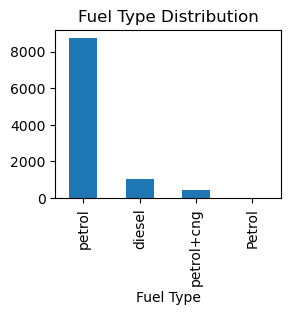

In [ ]:
# Fuel Type Distribution
plt.subplot(2, 2, 3)
df['Fuel Type'].value_counts().plot(kind='bar')
plt.title('Fuel Type Distribution')
plt.xlabel('Fuel Type')

In [40]:
# Convert Fuel Type to consistent format
df['Fuel Type'] = df['Fuel Type'].str.lower()

Text(0.5, 0, 'Fuel Type')

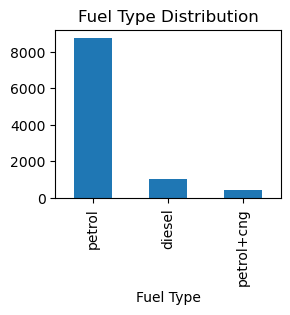

In [42]:
# Fuel Type Distribution
plt.subplot(2, 2, 3)
df['Fuel Type'].value_counts().plot(kind='bar')
plt.title('Fuel Type Distribution')
plt.xlabel('Fuel Type')

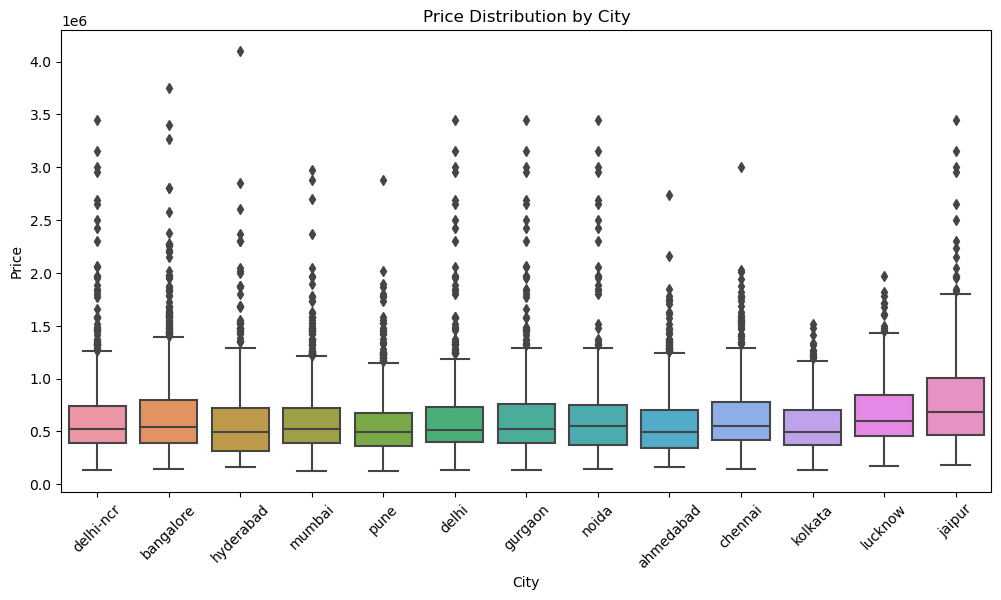

In [34]:
# Box plot of Price by City
plt.figure(figsize=(12, 6))
sns.boxplot(x='City', y='Price', data=df)
plt.title('Price Distribution by City')
plt.xticks(rotation=45)
plt.show()

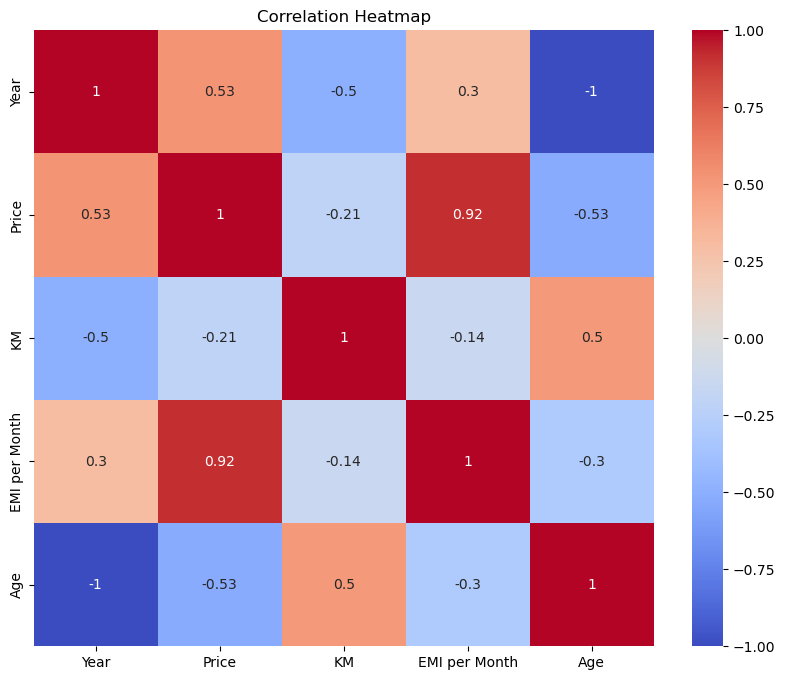

In [50]:
# Correlation Heatmap {to show the relation between all the numerical cols}
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [52]:
# Save cleaned and transformed data
df.to_csv('cleaned_car_data.csv', index=False)